<div style="background-color:#234c7d; border-radius:8px; padding:32px 40px 24px; margin-bottom:8px;">
  <h1 style="margin:0 0 6px; font-size:28px; font-weight:600; color:#C49A28; letter-spacing:-0.5px;">GA Image Approximation</h1>
  <p style="margin:0; font-size:13px; color:#a8b8d0; letter-spacing:0.5px;">Challenge 1 - Fitness Function Comparison & Multi-Objective Optimisation</p>
</div>
<div style="border:1.5px solid #234c7d; border-radius:8px; padding:20px 40px; margin-bottom:8px; display:flex; gap:48px;">
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Group 35 - Convergence</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">Alexandra Rodrigues, 20250514 &nbsp;<br>Francisca Fernandes, 20250406 &nbsp;<br>Gonçalo Arrobas, 20250421 &nbsp;<br>Mariana Melo, 20250414 &nbsp;<br></p>
  </div>
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Course</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">Computational Intelligence for Optimization<br>MSc in Data Science &amp; Advanced Analytics<br>Nova Information Management School (NOVA IMS)<br>2025/2026</p>
  </div>
</div>

## **<span style="color:#234c7d">Table of Contents</span>**

**Part I - Single-Objective Fitness Comparison**
- [1. Introduction](#1-introduction)
- [2. Setup and Configuration](#2-setup-and-configuration)
- [3. Cross-Evaluation](#3-cross-evaluation)
- [4. Convergence Analysis](#4-convergence-analysis)
- [5. Population Dynamics](#5-population-dynamics)
- [6. Per-Region Analysis](#6-per-region-analysis)
- [7. Evolution Snapshots](#7-evolution-snapshots)

**Part II - Multi-Objective Optimisation (NSGA-II)**

- [8. NSGA-II Introduction](#8-nsga-ii-introduction)
- [9. Pareto Front Analysis](#9-pareto-front-analysis)
- [10. NSGA-II vs Single-Objective](#10-nsga-ii-vs-single-objective)
- [11. NSGA-II Visual Results](#11-nsga-ii-visual-results)

**Part III - Summary**

- [12. Conclusions](#12-conclusions)

# Part I - Single-Objective Fitness Comparison

# 1. Introduction

This notebook addresses **Challenge 1** from two angles. In Part I, we compare three independent GA runs each trained with a different single-objective fitness function. In Part II, we present an NSGA-II implementation that optimises RMSE and CIEDE2000 simultaneously, producing a Pareto front of trade-off solutions.

## Fitness Functions

### RMSE - Root Mean Squared Error
RMSE measures the average pixel-level difference between the generated and the original image, computed across all three RGB channels.

$$\text{RMSE} = \sqrt{\frac{1}{H \cdot W \cdot 3} \sum_{i,j,c} (I_{ijc} - \hat{I}_{ijc})^2}$$

| Symbol | Meaning |
|---|---|
| $H, W$ | Height and width of the image |
| $I_{ijc}$ | Original pixel value at position $(i,j)$, channel $c$ |
| $\hat{I}_{ijc}$ | Reconstructed pixel value |

**Limitation:** RGB distance is not perceptually uniform — a difference of 10 units in dark tones is far more noticeable to the human eye than the same difference in mid-tones, but RMSE treats both equally. The GA may waste triangles reducing numerical error in low-salience regions (the large dark background) while underinvesting in visually important regions like the face and headscarf.

**Expected behaviour:** lowest pixel error, but not necessarily the most visually faithful result.


### CIEDE2000 - Perceptual Colour Difference
CIEDE2000 (ΔE₀₀) addresses the main limitation of RMSE by operating in the **CIELAB colour space**, which is designed to be **perceptually uniform** — equal numerical distances correspond to equally noticeable colour differences. Before computing the error, both images are converted from sRGB to CIELAB via gamma expansion and a linear matrix transform.

The metric does two things RMSE does not:

**1. Changes the colour space** — distances are computed in CIELAB, where the geometry of the space already reflects human perception. A difference of 10 units looks roughly the same to the human eye regardless of where in the colour space it occurs.

**2. Applies perceptual correction terms** — CIEDE2000 introduces three scaling factors that adjust the penalty based on local colour properties:
- **S_L** — lightness: errors in very dark or very bright regions are penalised less
- **S_C** — chroma: errors in highly saturated colours are penalised less
- **S_H** — hue: errors in blue regions are penalised less (relevant for the headscarf)

$$\Delta E_{00} = \sqrt{\left(\frac{\Delta L'}{S_L}\right)^2 + \left(\frac{\Delta C'}{S_C}\right)^2 + \left(\frac{\Delta H'}{S_H}\right)^2 + R_T \cdot \frac{\Delta C'}{S_C} \cdot \frac{\Delta H'}{S_H}}$$

| Symbol | Meaning |
|---|---|
| $\Delta L', \Delta C', \Delta H'$ | Lightness, chroma and hue differences |
| $S_L, S_C, S_H$ | Perceptual weighting functions |
| $R_T$ | Rotation term — corrects for the blue-purple hue region |

**Expected behaviour:** lower perceptual colour error and better colour fidelity in the face and headscarf, at the cost of higher RMSE.


### SSIM - Structural Similarity Index
SSIM measures image quality by jointly capturing **luminance**, **contrast**, and **local structure** in sliding 11×11 pixel windows, rather than comparing individual pixels. It correlates better with human perception than RMSE and is widely used in image quality research — if it worked as a fitness function, it would reward the GA for preserving structural identity (edges, contours, contrast transitions) rather than just colour accuracy. It was however designed for scenarios where the generated image is already close to the reference.

$$\text{SSIM}(x, y) = \underbrace{\frac{2\mu_x\mu_y + C_1}{\mu_x^2 + \mu_y^2 + C_1}}_{l(x,y)} \cdot \underbrace{\frac{2\sigma_x\sigma_y + C_2}{\sigma_x^2 + \sigma_y^2 + C_2}}_{c(x,y)} \cdot \underbrace{\frac{\sigma_{xy} + C_3}{\sigma_x\sigma_y + C_3}}_{s(x,y)}$$

| Symbol | Meaning |
|---|---|
| $\mu_x, \mu_y$ | Mean pixel intensity in each window |
| $\sigma_x, \sigma_y$ | Standard deviation of pixel intensities |
| $\sigma_{xy}$ | Cross-covariance between the two windows |
| $C_1, C_2, C_3$ | Stability constants to avoid division by zero |

The final score is the mean over all windows in $[-1, 1]$; we use $1 - \text{SSIM}$ to conform to the minimisation convention.

**Known limitation for this task:** SSIM only improves when the surrounding neighbourhood of pixels is also correct — a well-placed triangle surrounded by wrong-coloured neighbours contributes negligibly to the score. This produces a weaker optimisation signal in early generations compared to RMSE and CIEDE2000, which reward each pixel independently. We include SSIM to empirically assess this limitation.

**Expected behaviour:** visually incorrect results, particularly wrong colours, as the GA may optimise structural patterns at the expense of colour accuracy. Whether this limitation is fatal or merely harmful is an empirical question the results will answer.


## Experimental Setup

All three GAs use the same best operator configuration found in Phases 1–11, ensuring differences in output quality are attributable solely to the fitness function.

| Component | Choice |
|---|---|
| Selection | Tournament k=10 |
| Crossover | Blend α=0.5 |
| Mutation | Gaussian Decay σ: 80→2 |
| Elitism | 3 elites |
| Init strategy | Quadrant |
| Generations | 3000 |
| Seeds | 42, 43, 44 |


# 2. Setup and Configuration

In [106]:
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sys.path.insert(0, '../src')
from fitness import RMSEFitness, CIEDEFitness, SSIMFitness
from utils import load_target, render, triangles_from_json

BLUE   = '#002654'
GOLD   = '#C49A28'
LIGHT  = '#a8b8d0'
COLORS = {'RMSE': '#002654', 'CIEDE2000': '#C49A28', 'SSIM': '#4C72B0'}

plt.rcParams['figure.dpi']          = 120
plt.rcParams['font.size']           = 11
plt.rcParams['axes.spines.top']     = False
plt.rcParams['axes.spines.right']   = False

os.makedirs('../outputs', exist_ok=True)
print('Setup complete.')

Setup complete.


In [4]:
RUNNER_OUTPUTS = '../runner_outputs'
TARGET_PATH    = '../data/Girl_Pearl_Earing.png'
SEEDS          = [42, 43, 44]

# Folder paths for each run (update RMSE path after seeds 43/44 finish)
RUN_FOLDERS = {
    'RMSE':      'p10_rate_001_sigmax_80',
    'CIEDE2000': 'p13_fitness_ciede2000/p13_fitness_ciede2000',
    'SSIM':      'p13_fitness_ssim/p13_fitness_ssim',
}

# MO-GA folder (update after NSGA-II runs)
MO_FOLDER = 'mo_ga'

def load_log(run_folder, seed):
    path = os.path.join(RUNNER_OUTPUTS, run_folder, f'seed_{seed}', 'generation_log.json')
    if not os.path.exists(path):
        print(f'  WARNING: {path}')
        return None
    with open(path) as f:
        return json.load(f)

def get_curves(folder, key):
    curves = []
    for seed in SEEDS:
        log = load_log(folder, seed)
        if log:
            curves.append([e.get(key, float('nan')) for e in log])
    if not curves:
        return None, None, None
    n = min(len(c) for c in curves)
    arr = np.array([c[:n] for c in curves])
    return np.arange(n), arr.mean(axis=0), arr.std(axis=0)

def load_best_rendered(run_folder, seed):
    tpath = os.path.join(RUNNER_OUTPUTS, run_folder, f'seed_{seed}', 'best_final_triangles.json')
    if not os.path.exists(tpath):
        return None
    return render(triangles_from_json(tpath))

# Verify
print('Verifying files:')
for name, folder in RUN_FOLDERS.items():
    for seed in SEEDS:
        log = load_log(folder, seed)
        print(f'  {name} seed={seed}: {len(log)} gens' if log else f'  {name} seed={seed}: NOT FOUND')

Verifying files:
  RMSE seed=42: 3001 gens
  RMSE seed=43: 3001 gens
  RMSE seed=44: 3001 gens
  CIEDE2000 seed=42: 3001 gens
  CIEDE2000 seed=43: 3001 gens
  CIEDE2000 seed=44: 3001 gens
  SSIM seed=42: 3001 gens
  SSIM seed=43: 3001 gens
  SSIM seed=44: 3001 gens


# 3. Cross-Evaluation

Each best individual is evaluated against **all three metrics**, regardless of which fitness it was trained with. This is essential for a fair comparison: comparing a CIEDE-trained individual only by its CIEDE score would be circular. The table and charts below answer whether training with a perceptual metric also improves other dimensions of quality.

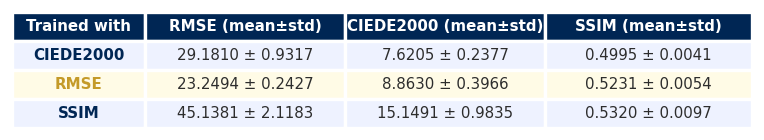

In [107]:
target   = load_target(TARGET_PATH)
rmse_fn  = RMSEFitness(target)
ciede_fn = CIEDEFitness(target)
ssim_fn  = SSIMFitness(target)

cross = []
for name, folder in RUN_FOLDERS.items():
    for seed in SEEDS:
        rendered = load_best_rendered(folder, seed)
        if rendered is None:
            continue
        cross.append({
            'trained_with': name,
            'seed': seed,
            'rmse':      rmse_fn.evaluate(rendered),
            'ciede2000': ciede_fn.evaluate(rendered),
            'ssim':      1.0 - ssim_fn.evaluate(rendered),
        })

df = pd.DataFrame(cross)

summary = df.groupby('trained_with').agg(
    rmse_mean=('rmse','mean'),      rmse_std=('rmse','std'),
    ciede_mean=('ciede2000','mean'), ciede_std=('ciede2000','std'),
    ssim_mean=('ssim','mean'),      ssim_std=('ssim','std'),
).round(4)

# Styled table
rows    = []
for name, row in summary.iterrows():
    rows.append([
        name,
        f"{row['rmse_mean']:.4f} ± {row['rmse_std']:.4f}",
        f"{row['ciede_mean']:.4f} ± {row['ciede_std']:.4f}",
        f"{row['ssim_mean']:.4f} ± {row['ssim_std']:.4f}",
    ])

headers = ['Trained with', 'RMSE (mean±std)', 'CIEDE2000 (mean±std)', 'SSIM (mean±std)']

row_bg  = ['#EEF2FF', '#FFFBE6', '#EEF2FF']
name_fg = [BLUE, GOLD, BLUE]
order   = ['CIEDE2000', 'RMSE', 'SSIM']
rows    = sorted(rows, key=lambda x: order.index(x[0]))

fig, ax = plt.subplots(figsize=(6.5, 1.3))
ax.axis('off')

table = ax.table(
    cellText=rows,
    colLabels=headers,
    colWidths=[0.18, 0.27, 0.27, 0.28],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1],
)

table.auto_set_font_size(False)
table.set_fontsize(9)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('white')
    cell.set_linewidth(2)
    if row == 0:
        cell.set_facecolor(BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_bg[row - 1])
        cell.set_text_props(
            color=name_fg[row - 1] if col == 0 else '#2d2d2d',
            fontweight='bold' if col == 0 else 'normal'
        )

plt.tight_layout()
plt.savefig('../outputs/challenge1_cross_table.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.1. Cross-Evaluation Interpretation

**RMSE GA** achieves the lowest pixel error (RMSE = 23.25 ± 0.24), as expected. However, it pays a perceptual cost: its mean CIEDE2000 score (8.86 ± 0.40) is 16% higher than the CIEDE-trained GA, meaning its colours are measurably less faithful to human perception despite being more accurate pixel-by-pixel. This confirms a known limitation of RGB-based metrics: they treat all pixels equally regardless of visual salience.

**CIEDE2000 GA** achieves the best perceptual colour accuracy (CIEDE2000 = 7.62 ± 0.24), a 14% improvement over the RMSE GA on this metric. The trade-off is a higher pixel error (RMSE = 29.18 ± 0.93) — the GA redistributed its optimisation effort away from low-salience regions (the dark background) towards regions where colour errors are most perceptible to the human eye. This redistribution is the central prediction of using a perceptual metric as fitness, and the data supports it. Notably, the CIEDE2000 GA also exhibits lower variance across seeds (std = 0.24 vs 0.40 on CIEDE), suggesting it converges to more stable solutions.

**SSIM GA** performs worst across all metrics — RMSE = 45.14, CIEDE = 15.15 — nearly double the error of the other two GAs. Its SSIM similarity advantage (0.532 vs ~0.500–0.523) is negligible on a [0,1] scale. The results confirm that optimising for SSIM produces images with recognisable structure but wrong colours — the GA learned to optimise what SSIM penalises (local patterns and contrast) while ignoring what it does not (absolute colour accuracy).

**Key takeaway:** the choice of fitness function shapes what the GA learns. RMSE and CIEDE2000 represent two legitimate but different definitions of image quality. For a painterly approximation task where the goal is visual resemblance to a human observer, CIEDE2000 is the more appropriate metric.

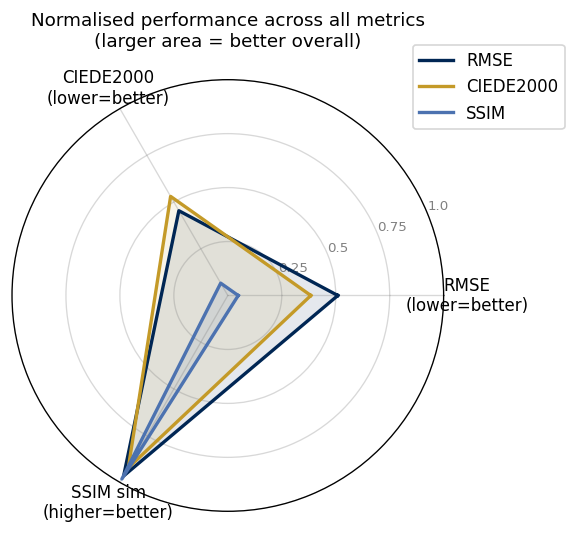

In [108]:
metrics_radar = ['RMSE\n(lower=better)', 'CIEDE2000\n(lower=better)', 'SSIM sim\n(higher=better)']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

for name, color in COLORS.items():
    subset = df[df['trained_with'] == name]
    rmse_norm  = 1 - (subset['rmse'].mean()  / df['rmse'].max())
    ciede_norm = 1 - (subset['ciede2000'].mean() / df['ciede2000'].max())
    ssim_norm  = subset['ssim'].mean() / df['ssim'].max()
    values = [rmse_norm, ciede_norm, ssim_norm]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=name)
    ax.fill(angles, values, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8, color='grey')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.set_title('Normalised performance across all metrics\n(larger area = better overall)', 
             fontsize=11, pad=20)
ax.grid(color='grey', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/challenge1_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2. Radar Chart Interpretation

The radar chart makes the trade-off between fitness functions immediately visible. Each axis is normalised so that 1.0 = best possible performance on that metric; larger area means better overall performance.

**RMSE and CIEDE2000 exhibit complementary trade-offs rather than a clear global winner.** The RMSE GA (dark blue) extends further on the RMSE axis, while the CIEDE2000 GA (gold) extends further on the CIEDE2000 axis. On the SSIM similarity axis, both are nearly identical. This symmetry is not a coincidence, it is a direct consequence of the trade-off: optimising pixel accuracy comes at the cost of perceptual colour fidelity, and vice versa. Neither GA dominates the other globally, they represent two equally valid but different solutions depending on what quality means in context.

**The SSIM GA (light blue) occupies a much smaller area across all three axes.** Despite having a marginally higher SSIM similarity score, the improvement is visually negligible compared to the severe degradation on RMSE and CIEDE2000. 

**The key insight from this chart is the absence of a clear overall winner between RMSE and CIEDE2000.** For a painterly approximation task where the goal is visual resemblance to a human observer, CIEDE2000 would be the natural choice, it directly optimises for what the eye perceives rather than what a formula counts. The two GAs occupy different regions of the performance space, confirming that the choice of fitness function is a genuine design decision with real consequences, not a free parameter.


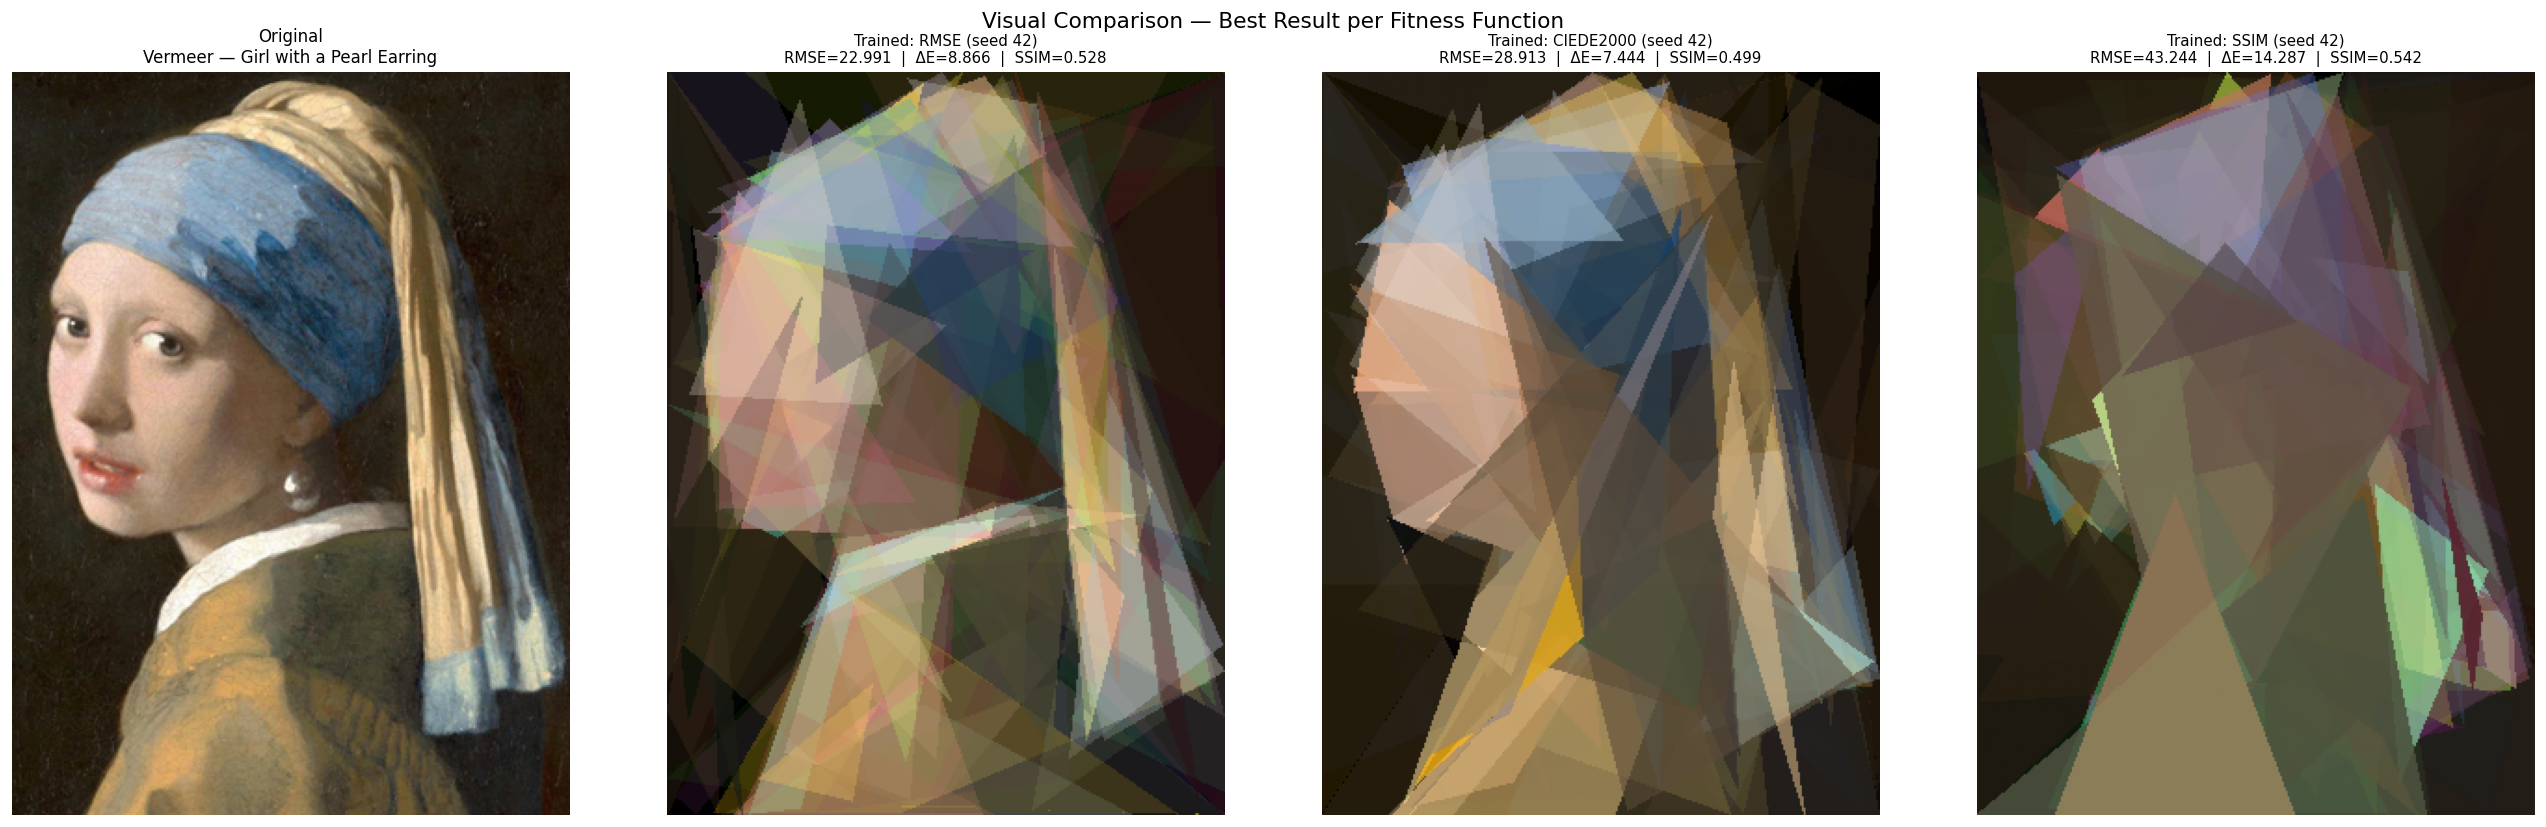

In [ ]:
metric_cols = {'RMSE': 'rmse', 'CIEDE2000': 'ciede2000', 'SSIM': 'ssim'}
target_img  = mpimg.imread(TARGET_PATH)

fig, axes = plt.subplots(1, 4, figsize=(22, 7))
axes[0].imshow(target_img)
axes[0].set_title('Original\nVermeer — Girl with a Pearl Earring', fontsize=10)
axes[0].axis('off')

for ax, (name, folder) in zip(axes[1:], RUN_FOLDERS.items()):
    subset = df[df['trained_with'] == name]
    col    = metric_cols[name]
    best_seed = int(subset.loc[subset[col].idxmax() if name == 'SSIM' else subset[col].idxmin(), 'seed'])
    img_path  = os.path.join(RUNNER_OUTPUTS, folder, f'seed_{best_seed}', 'best_final.png')
    if not os.path.exists(img_path):
        ax.text(0.5, 0.5, 'not found', ha='center', va='center')
        ax.axis('off')
        continue
    row = subset[subset['seed'] == best_seed].iloc[0]
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(
        f'Trained: {name} (seed {best_seed})\n'
        f'RMSE={row["rmse"]:.3f}  |  ΔE={row["ciede2000"]:.3f}  |  SSIM={row["ssim"]:.3f}',
        fontsize=9
    )
    ax.axis('off')

plt.suptitle('Visual Comparison — Best Result per Fitness Function', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/challenge1_visual.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3. Visual Comparison

At first glance, RMSE appears more detailed: more triangles visibly contributing, richer layering, more complex structure. But looking at the colours, the skin tone has a cold, slightly off hue, and the headscarf mixes blues with greens and purples that are not in the original.

CIEDE2000 tells the opposite story. The image is coarser and less detailed, but the colours are immediately more faithful: the skin tone is warmer and closer to the original, the blue headscarf reads as blue rather than a colour mix, and the dark background is deeper. It loses detail but gains colour truth.

This is exactly the trade-off the metrics were designed to produce, and seeing it visually confirms what the numbers already suggested.

One important note: the operator configuration used for all three runs was optimised specifically for RMSE. CIEDE2000 and SSIM were tested with this same configuration without dedicated tuning — a configuration optimised for CIEDE2000 would likely close some of the visual gap.

# 4. Convergence Analysis

Convergence curves show how the best fitness and mean population fitness evolve over 3000 generations. Shaded bands represent ±1 standard deviation across the 3 seeds. What matters here is the **shape** of the curves: convergence speed, early vs late improvement, and stability across seeds.

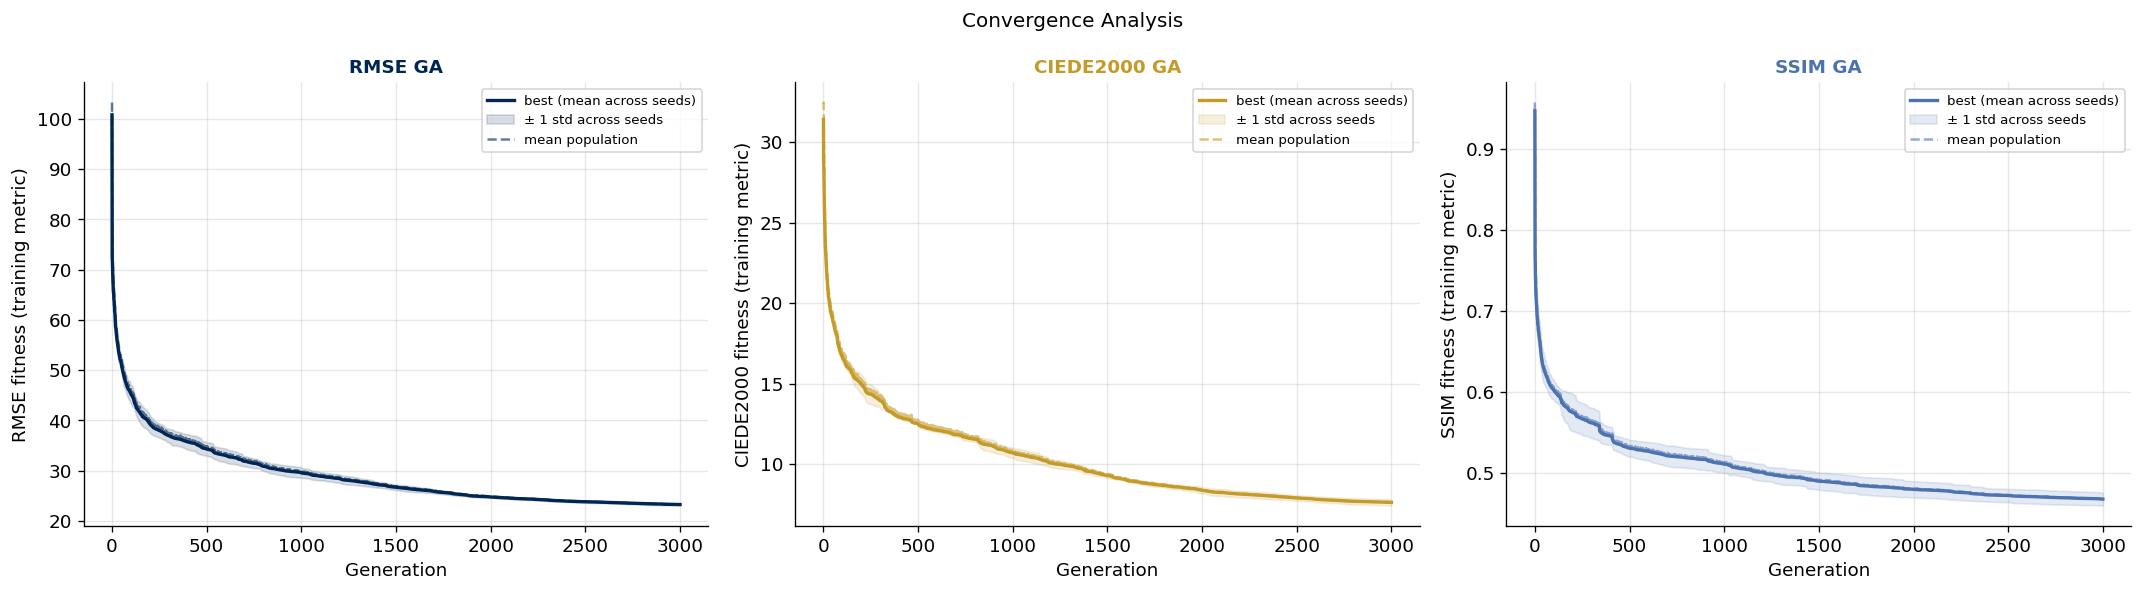

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, folder) in zip(axes, RUN_FOLDERS.items()):
    gens, mean, std = get_curves(folder, 'best')
    if gens is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        continue

    ax.plot(gens, mean, color=COLORS[name], lw=2, label='best (mean across seeds)')
    ax.fill_between(gens, mean - std, mean + std, alpha=0.15, color=COLORS[name],
                    label='± 1 std across seeds')

    # also plot mean population fitness on the same axis
    gens_m, mean_m, std_m = get_curves(folder, 'mean')
    if gens_m is not None:
        ax.plot(gens_m, mean_m, color=COLORS[name], lw=1.5, linestyle='--',
                alpha=0.6, label='mean population')

    ax.set_xlabel('Generation')
    ax.set_ylabel(f'{name} fitness (training metric)')
    ax.set_title(f'{name} GA', fontsize=11, fontweight='bold', color=COLORS[name])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Convergence Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/challenge1_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.1. Convergence Analysis Interpretation

**All three GAs share the same two-phase pattern** — steep descent in the first 200–300 generations, followed by gradual fine-tuning. This is driven by the problem and operator configuration.

**RMSE GA** — starts at ~100, reaches ~23 by generation 3000 (~77% reduction). Still visibly declining at generation 3000, consistent with the Phase 12 long-run results showing continued improvement beyond 3000 generations. The stable gap between best and mean confirms the population maintains healthy diversity throughout.

**CIEDE2000 GA** — the most striking feature is how tight the confidence band and the best–mean gap are. All three seeds converge to nearly the same solution, suggesting CIEDE2000 provides the cleanest and most consistent optimisation signal of the three.

**SSIM GA** — the curve is not flat. The GA makes genuine progress throughout 3000 generations, reaching 1−SSIM ≈ 0.46 (SSIM similarity = 0.54). However, the wider confidence band reflects less stable convergence across seeds, and — as the visual comparison shows — the GA converges to a poor solution: it optimises structural patterns without correcting colour.

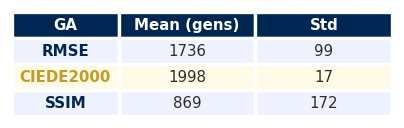

In [35]:
conv_data = {}
for name, folder in RUN_FOLDERS.items():
    gens_list = []
    for seed in SEEDS:
        log = load_log(folder, seed)
        if not log: continue
        values    = [e['best'] for e in log]
        final     = values[-1]
        threshold = final * 1.10
        for g, v in enumerate(values):
            if v <= threshold:
                gens_list.append(g)
                break
    if gens_list:
        conv_data[name] = (int(np.mean(gens_list)), int(np.std(gens_list)))

fig, ax = plt.subplots(figsize=(3.5, 1.2))
ax.axis('off')

rows    = [[name, f"{v[0]}", f"{v[1]}"] for name, v in conv_data.items()]
headers = ['GA', 'Mean (gens)', 'Std']

table = ax.table(
    cellText=rows,
    colLabels=headers,
    colWidths=[0.28, 0.36, 0.36],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1],
)

table.auto_set_font_size(False)
table.set_fontsize(9)

row_bg  = ['#EEF2FF', '#FFFBE6', '#EEF2FF']
name_fg = [BLUE, GOLD, BLUE]

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('white')
    cell.set_linewidth(2)
    if row == 0:
        cell.set_facecolor(BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_bg[row - 1])
        cell.set_text_props(
            color=name_fg[row - 1] if col == 0 else '#2d2d2d',
            fontweight='bold' if col == 0 else 'normal'
        )

plt.tight_layout()
plt.savefig('../outputs/challenge1_conv_speed_table.png', dpi=150, bbox_inches='tight')
plt.show()

**RMSE** reaches 110% of its final best at generation 1736 (std=99), converging steadily through the mid-run.

**CIEDE2000** takes the longest — 1998 generations (std=17), but with the lowest variance by far. This confirms what the convergence curves showed: CIEDE2000 continues improving for longer and does so consistently across seeds.

**SSIM** appears to converge fastest at generation 869, but this is misleading, it reaches its ceiling early, not because it found a good solution but because it ran out of diversity to improve further as we will see later.

# 5. Population Dynamics

**Diversity** (phenotypic variance) measures how spread the population is: a premature collapse indicates the GA stopped exploring too early. 

**Population spread** (mean − best) measures the gap between average and best individual: approaching zero means convergence.

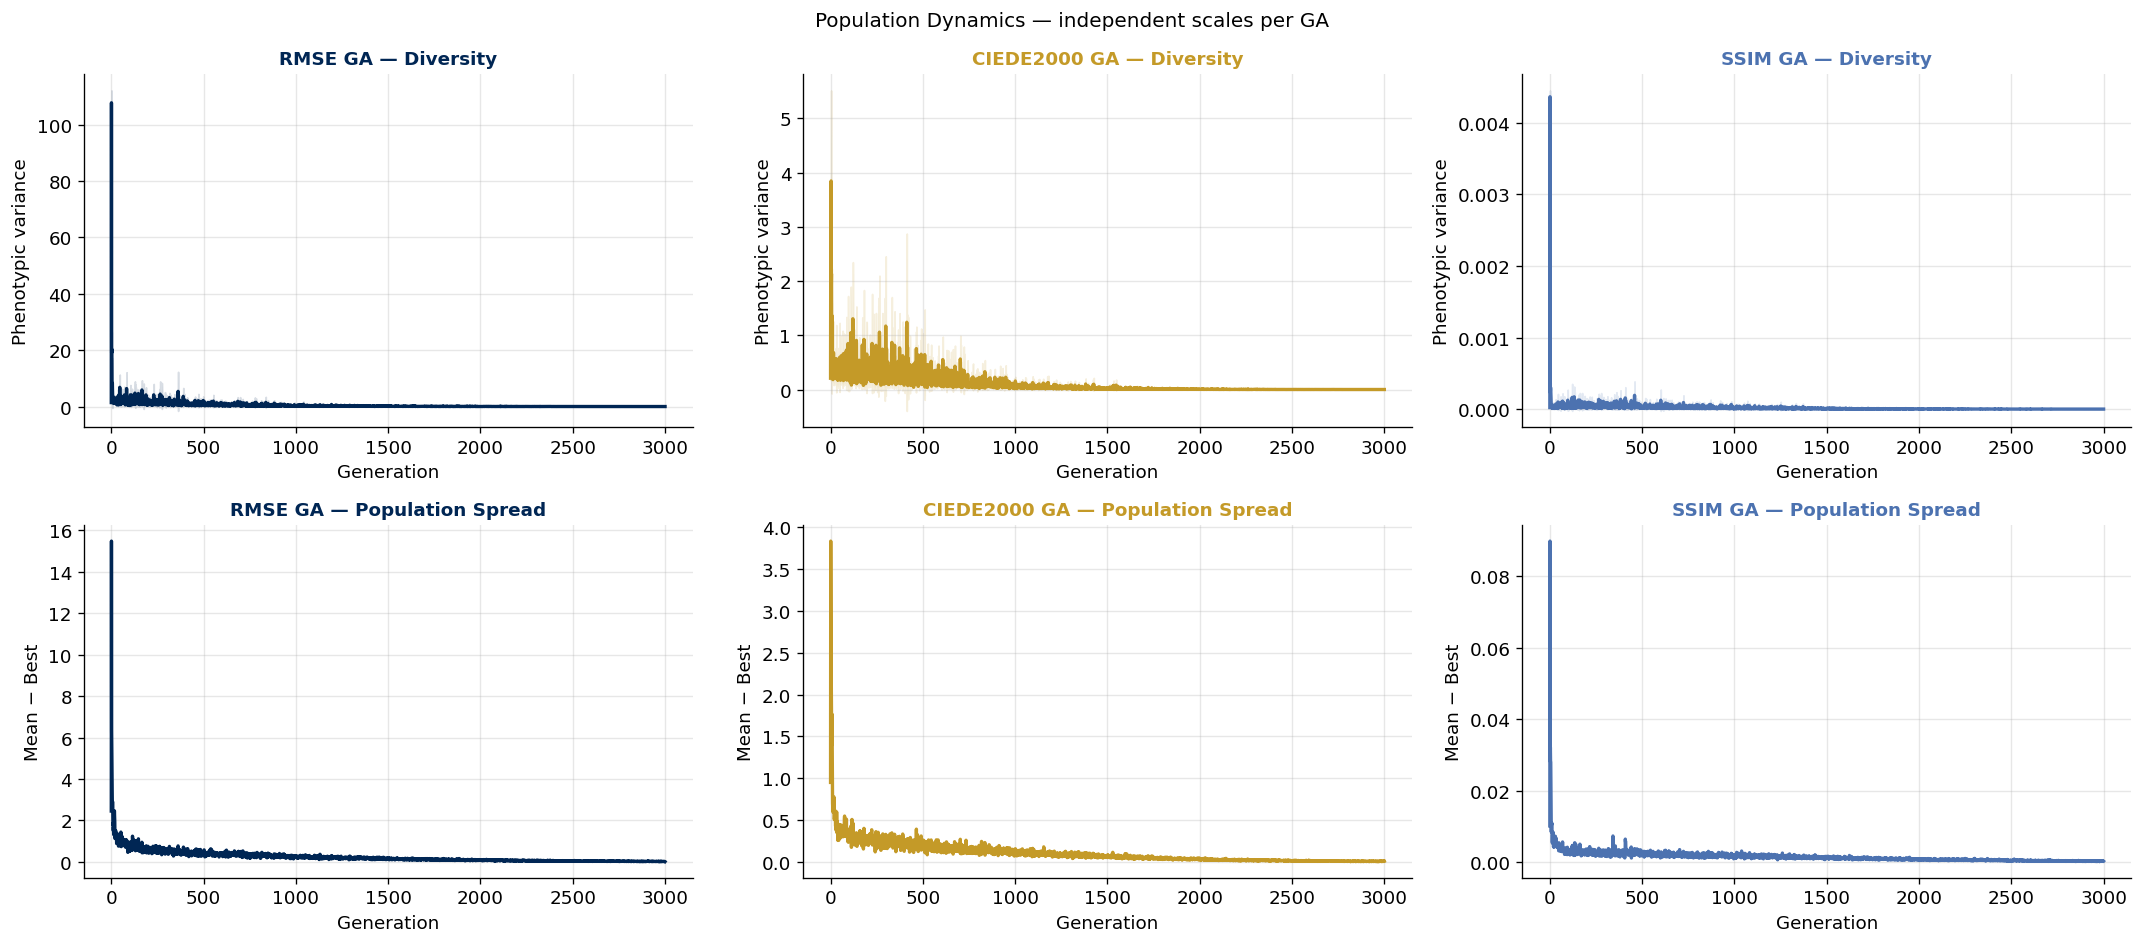

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for col, (name, folder) in enumerate(RUN_FOLDERS.items()):

    ax = axes[0, col]
    gens, mean, std = get_curves(folder, 'diversity')
    if gens is not None:
        ax.plot(gens, mean, color=COLORS[name], lw=2)
        ax.fill_between(gens, mean-std, mean+std, alpha=0.15, color=COLORS[name])
    ax.set_xlabel('Generation')
    ax.set_ylabel('Phenotypic variance')
    ax.set_title(f'{name} GA — Diversity', fontsize=11,
                 fontweight='bold', color=COLORS[name])
    ax.grid(alpha=0.3)

    ax = axes[1, col]
    _, mb, _ = get_curves(folder, 'best')
    _, mm, _ = get_curves(folder, 'mean')
    if mb is not None and mm is not None:
        n = min(len(mb), len(mm))
        ax.plot(np.arange(n), mm[:n] - mb[:n], color=COLORS[name], lw=2)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Mean − Best')
    ax.set_title(f'{name} GA — Population Spread', fontsize=11,
                 fontweight='bold', color=COLORS[name])
    ax.grid(alpha=0.3)

plt.suptitle('Population Dynamics — independent scales per GA', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/challenge1_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.1. Population Dynamics Interpretation

**RMSE GA** — diversity starts very high (~107) at generation 0 due to the quadrant initialisation, collapses sharply within the first 100 generations, then stabilises at a low but non-zero level. The persistent residual spread (mean − best ≈ 0.5–1.0) confirms the population never fully converges — consistent with the still-declining convergence curve at generation 3000.

**CIEDE2000 GA** — the most interesting dynamics. Diversity shows a pronounced oscillatory pattern between generations 200–800, with repeated spikes before decaying smoothly. This is the sigma decay scheduler at work: still providing large perturbations that occasionally disrupt the population, which selection pressure then corrects. This structured exploration-then-exploitation transition explains why CIEDE2000 achieves the most stable and consistent final results.

**SSIM GA** — unlike CIEDE2000, there is no oscillatory recovery: the population converges rapidly to a narrow region and never recovers the variation needed to correct colour accuracy.

# 6. Per-Region Analysis

We divide the image into four semantically meaningful regions and compute RMSE separately for each. This quantifies whether CIEDE2000 genuinely redistributes optimisation effort towards perceptually important regions.

| Region | Rectangles | Content |
|---|---|---|
| Background | rows 0–50, cols 0–60 | Top-left dark corner |
| | rows 250–400, cols 0–60 | Bottom-left dark strip |
| | rows 0–150, cols 240–300 | Right dark strip |
| Face | rows 100–250, cols 20–140 | Skin, eyes, lips |
| Headscarf | rows 30–100, cols 30–230 | Blue headscarf top |
| | rows 100–190, cols 140–250 | Blue headscarf middle |
| | rows 190–352, cols 210–300 | Golden veil |
| Body | rows 260–400, cols 60–225 | Clothing |

In [54]:
def region_rmse(rendered_f, target_f, slices):
    sq_errors = []
    for rrow, rcol in slices:
        t_crop = target_f[rrow, rcol].astype(np.float32)
        r_crop = rendered_f[rrow, rcol].astype(np.float32)
        sq_errors.append(((t_crop - r_crop) ** 2).flatten())
    return float(np.sqrt(np.mean(np.concatenate(sq_errors))))

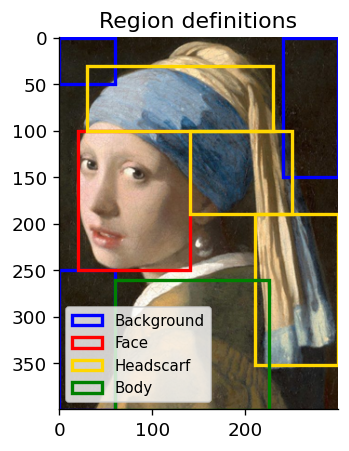

In [ ]:
import matplotlib.patches as patches

REGIONS = [
    ('Background', [(slice(0, 50), slice(0,   60)), 
                    (slice(250, 400), slice(0,   60)),
                    (slice(0, 150), slice(240, 300))]),
    ('Face',       [(slice(100, 250), slice(20, 140))]),
    ('Headscarf',  [(slice(30,  100), slice(30, 230)),
                    (slice(100,  190), slice(140, 250)),
                    (slice(190,  352), slice(210, 300))]),
    ('Body',       [(slice(260, 400), slice(60, 225))]),
]

REGION_COLORS = ['blue', 'red', 'gold', 'green']

fig, ax = plt.subplots(figsize=(3, 5))
ax.imshow(target_arr.astype(np.uint8))

for (rname, rslices), color in zip(REGIONS, REGION_COLORS):
    added_label = False
    for rrow, rcol in rslices:
        rect = patches.Rectangle(
            (rcol.start, rrow.start),
            rcol.stop - rcol.start,
            rrow.stop - rrow.start,
            linewidth=2, edgecolor=color, facecolor='none',
            label=rname if not added_label else '_nolegend_'
        )
        ax.add_patch(rect)
        added_label = True

ax.legend(fontsize=9)
ax.set_title('Region definitions')
plt.show()

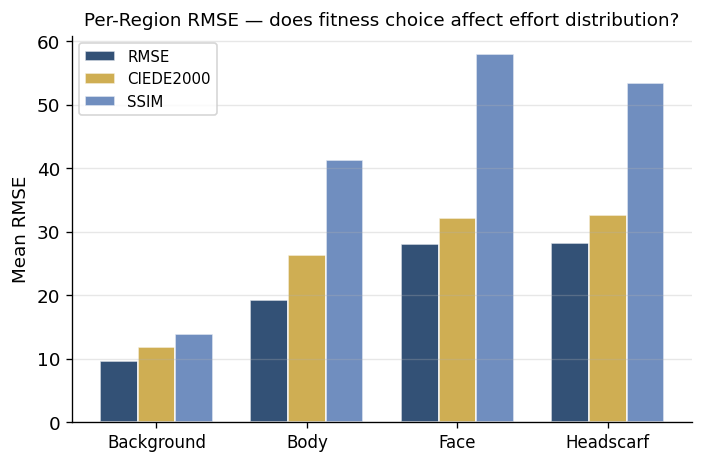

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
x     = np.arange(len(pivot.columns))
width = 0.25

for i, (name, color) in enumerate(COLORS.items()):
    if name not in pivot.index:
        continue
    vals = [pivot.loc[name, r] for r in pivot.columns]
    ax.bar(x + i * width, vals, width, label=name,
           color=color, alpha=0.8, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_ylabel('Mean RMSE')
ax.set_title('Per-Region RMSE — does fitness choice affect effort distribution?', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/challenge1_regions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.1. Per-Region Analysis Interpretation

**Background**: all three GAs perform similarly (RMSE~10, CIEDE~11.5, SSIM~14). The dark uniform background is easy to approximate regardless of metric and does not drive differentiation.

**The gap between RMSE and CIEDE2000 widens in more complex regions.** In the Background the difference is ~1.5 RMSE units; it grows to ~6.5 in the Body and remains elevated at ~3.5-4 in the Face and Headscarf. This is the redistribution effect: CIEDE2000 accepts higher pixel error in regions with more complex colour structure in exchange for better perceptual colour fidelity.

**SSIM shows disproportionate degradation in perceptually salient regions**: errors of ~58 in the Face and ~53 in the Headscarf, versus ~14 in the Background. The face-to-background error ratio is nearly 4:1 for SSIM versus 3:1 for RMSE, confirming the SSIM GA fails most severely precisely where accurate colour matters most.

# 7. Evolution Snapshots

Checkpoint images at fixed generation intervals (seed 42). Shows how each GA evolves visually over time and whether colour fidelity or structural accuracy develops first.

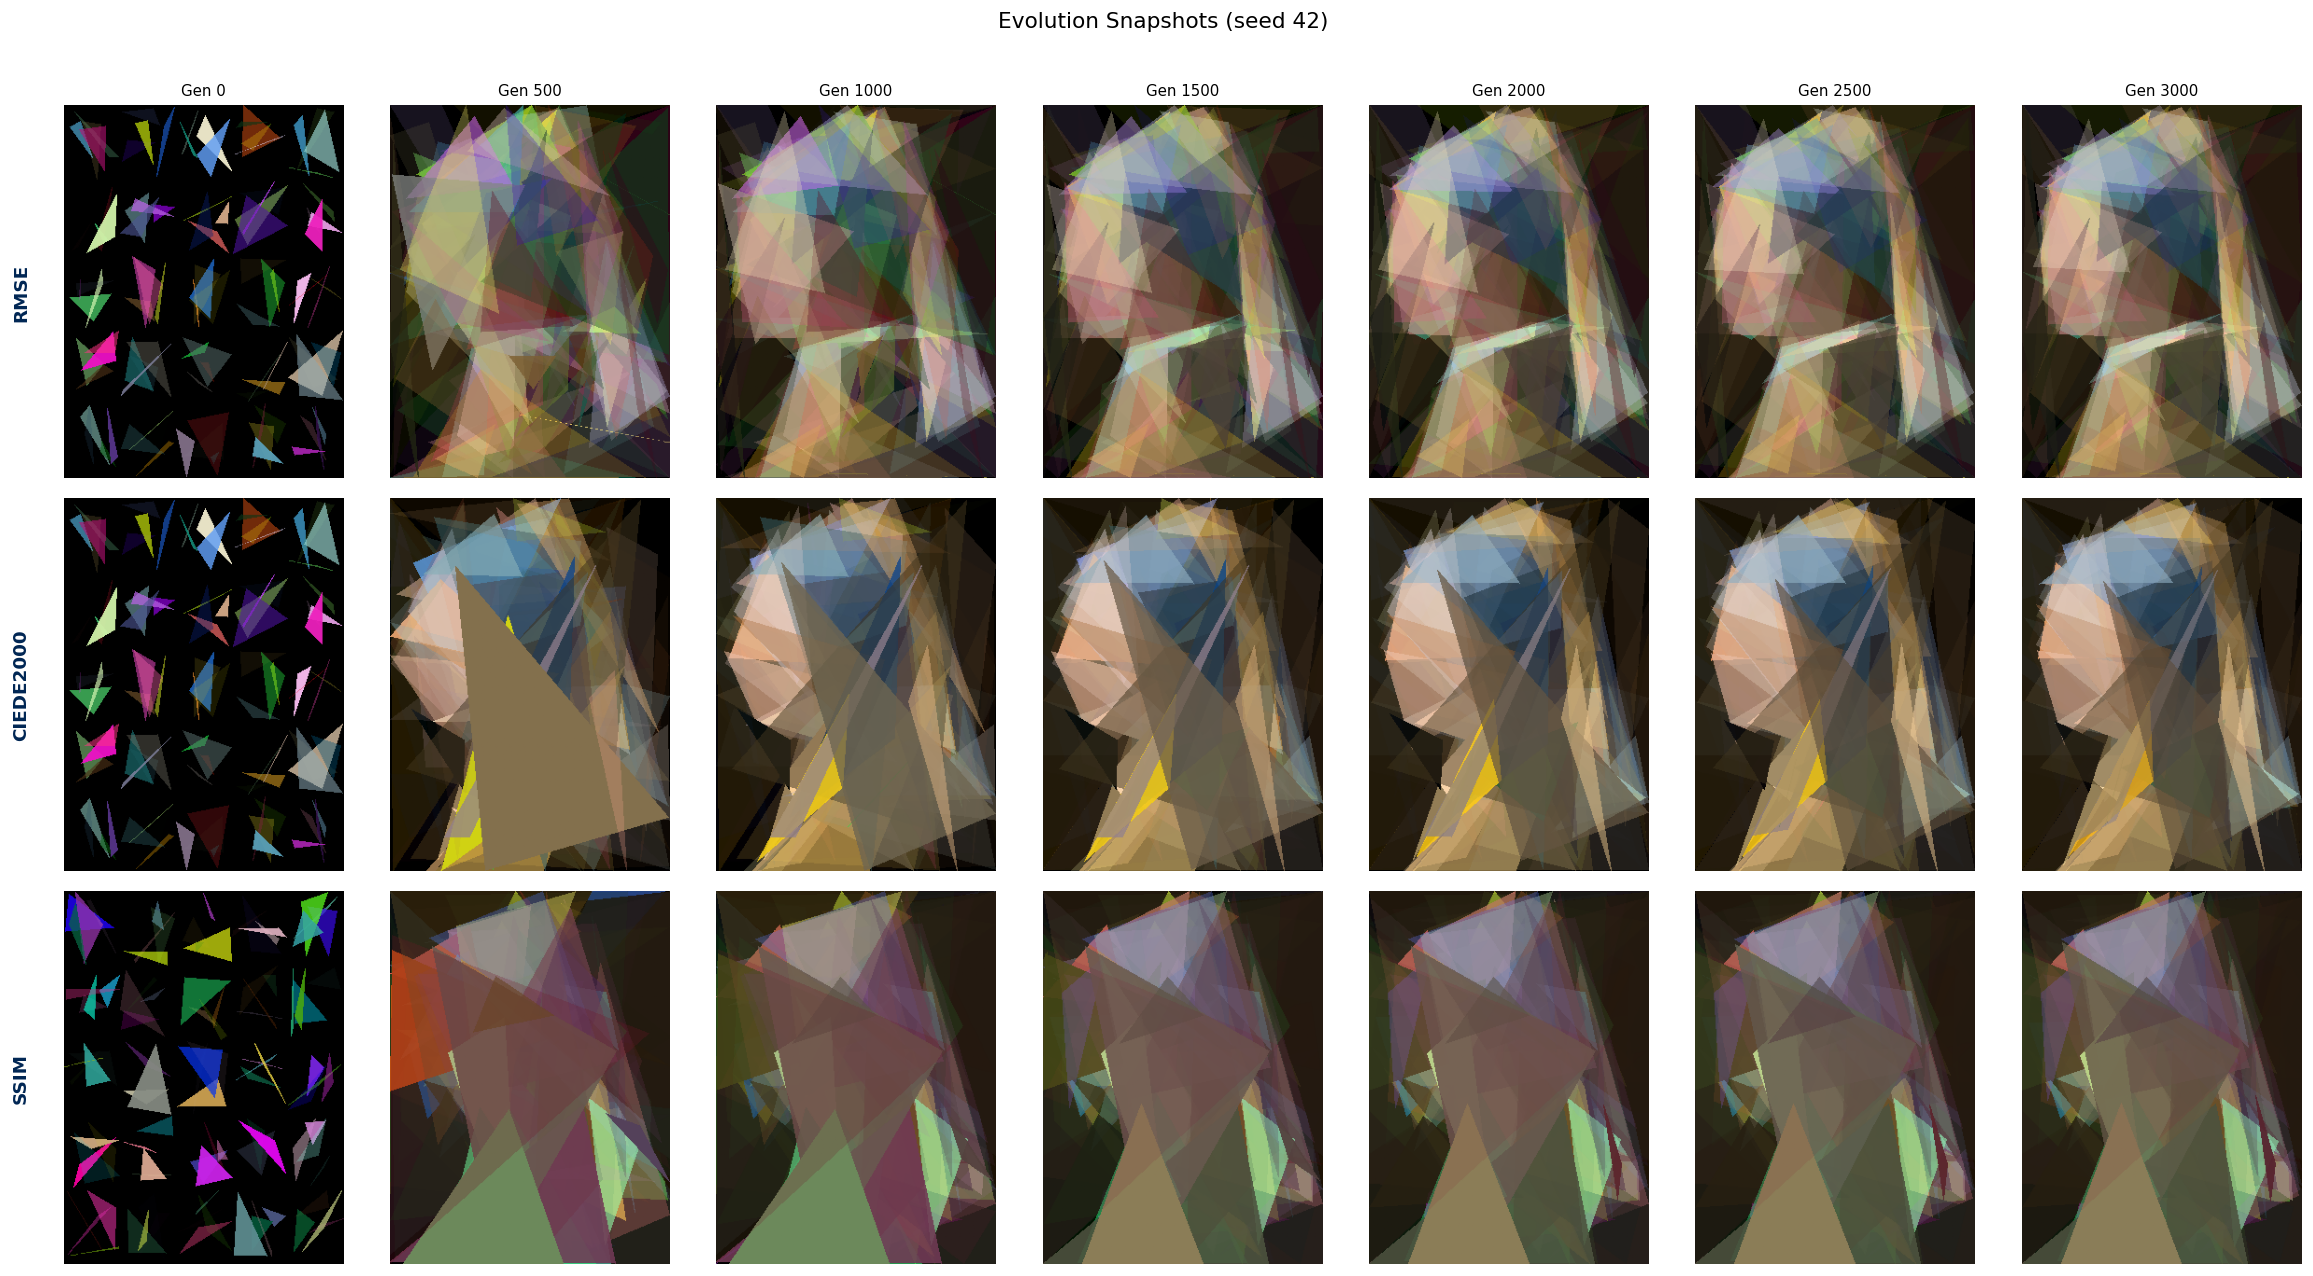

In [13]:
CKPT_GENS = [0, 500, 1000, 1500, 2000, 2500, 3000]
REF_SEED  = 42

fig, axes = plt.subplots(len(RUN_FOLDERS), len(CKPT_GENS),
                         figsize=(len(CKPT_GENS)*2.8, len(RUN_FOLDERS)*3.5))

for ri, (name, folder) in enumerate(RUN_FOLDERS.items()):
    for ci, gen in enumerate(CKPT_GENS):
        ax  = axes[ri, ci]
        img = os.path.join(RUNNER_OUTPUTS, folder, f'seed_{REF_SEED}',
                           'checkpoints', f'gen_{gen:04d}.png')
        if os.path.exists(img):
            ax.imshow(mpimg.imread(img))
        else:
            ax.text(0.5, 0.5, f'gen {gen}\nnot found', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='#888')
        ax.axis('off')
        if ri == 0: ax.set_title(f'Gen {gen}', fontsize=9)
        if ci == 0: ax.text(-0.12, 0.5, name, transform=ax.transAxes,
                            fontsize=11, fontweight='bold', va='center',
                            ha='right', rotation=90, color=BLUE)

plt.suptitle(f'Evolution Snapshots (seed {REF_SEED})', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/challenge1_evolution.png', dpi=130, bbox_inches='tight')
plt.show()

## 7.1. Evolution Snapshots Interpretation

**CIEDE2000 has correct colours by generation 500.** The skin tone, blue headscarf, dark background and golden veil are all in the right place and at the right hue. From generation 500 onwards the GA refines geometry — the colours are already committed. CIEDE2000 provides a strong early signal for colour placement.

**RMSE takes longer to commit to correct colours.** At generation 500 the image is still heavily transparent and colour-mixed, with incorrect regions persisting until generation 1500+. RMSE receives equal signal from all pixels regardless of colour importance, so colour and position are explored simultaneously for longer.

**SSIM establishes structure early but never corrects colour.** The silhouette is recognisable from generation 500 and changes little afterwards — the wrong colours at generation 500 are essentially the same wrong colours at generation 3000. The early diversity collapse seen in Section 5 is visible here: the GA commits to a structural solution before ever finding correct colours, and cannot escape.

# Part II - Multi-Objective Optimisation (NSGA-II)

# 8. NSGA-II Introduction

The single-objective GAs in Part I each optimise one metric and implicitly sacrifice the others. A more principled approach is to optimise RMSE and CIEDE2000 **simultaneously**, letting the algorithm find the full set of solutions where no improvement in one metric is possible without degrading the other.

The foundation of this approach is the concept of **Pareto dominance** (Vanneschi & Silva, 2023). A solution $A$ dominates solution $B$ if $A$ is better than or equal to $B$ on all objectives, and strictly better on at least one. Solutions that are not dominated by any other solution in the population are called **non-dominated solutions**, and their set is the **Pareto optimal set** — or Pareto front. Rather than returning a single best solution, multi-objective optimisation returns this set, where each member represents a different trade-off between the objectives.

To integrate Pareto optimality into a GA, individuals are ranked by non-dominance: all non-dominated individuals receive rank 1, are removed from the population, and the process repeats on the remaining individuals to assign rank 2, and so on. Selection probability is then inversely proportional to rank — rank 1 individuals are most likely to be selected (Baker, 1985, as described in Vanneschi & Silva, 2023). NSGA-II (Deb et al., 2002) extends this approach with two key additions:

1. **Crowding distance** — within the same rank, individuals in sparse regions of objective space are preferred, maintaining diversity along the front.
2. **Environmental selection** — parent and offspring populations are combined (size 2N) and the best N individuals are selected by (rank, crowding distance), providing implicit elitism.

The same crossover and mutation operators from the single-objective GA are used unchanged — only the fitness evaluation and selection components differ.

**Why RMSE and CIEDE2000, and not SSIM?** The results in Part I showed that SSIM fails as an optimisation objective for this task: the loss surface is nearly flat in early generations, the population loses diversity prematurely, and the GA never recovers. Including SSIM as a third objective would introduce a noisy, uninformative signal that would degrade the quality of the Pareto front without adding meaningful trade-off information. RMSE and CIEDE2000 both provide strong, consistent optimisation signals and represent genuinely different definitions of image quality — pixel accuracy versus perceptual colour fidelity — making their trade-off the natural focus of the multi-objective analysis.

In [ ]:
def load_pareto_front(seed):
    path = os.path.join(RUNNER_OUTPUTS, MO_FOLDER, f'seed_{seed}', 'pareto_front.json')
    if not os.path.exists(path):
        print(f'  WARNING: Pareto front not found: {path}')
        return None
    with open(path) as f:
        return json.load(f)

mo_fronts = {}
for seed in SEEDS:
    front = load_pareto_front(seed)
    if front:
        mo_fronts[seed] = front
        print(f'  seed={seed}: Pareto front size = {len(front)}')

print(f'\nLoaded fronts for {len(mo_fronts)}/{len(SEEDS)} seeds.')

  seed=42: Pareto front size = 47
  seed=43: Pareto front size = 16
  seed=44: Pareto front size = 82

Loaded fronts for 3/3 seeds.


# 9. Pareto Front Analysis

The Pareto front is plotted as a scatter in RMSE × CIEDE2000 space. Each point is a non-dominated individual from the final population. The shape of the front reveals the trade-off: solutions in the top-left have low RMSE but high CIEDE; solutions in the bottom-right have low CIEDE but high RMSE. The curvature of the front shows how steep the trade-off is.

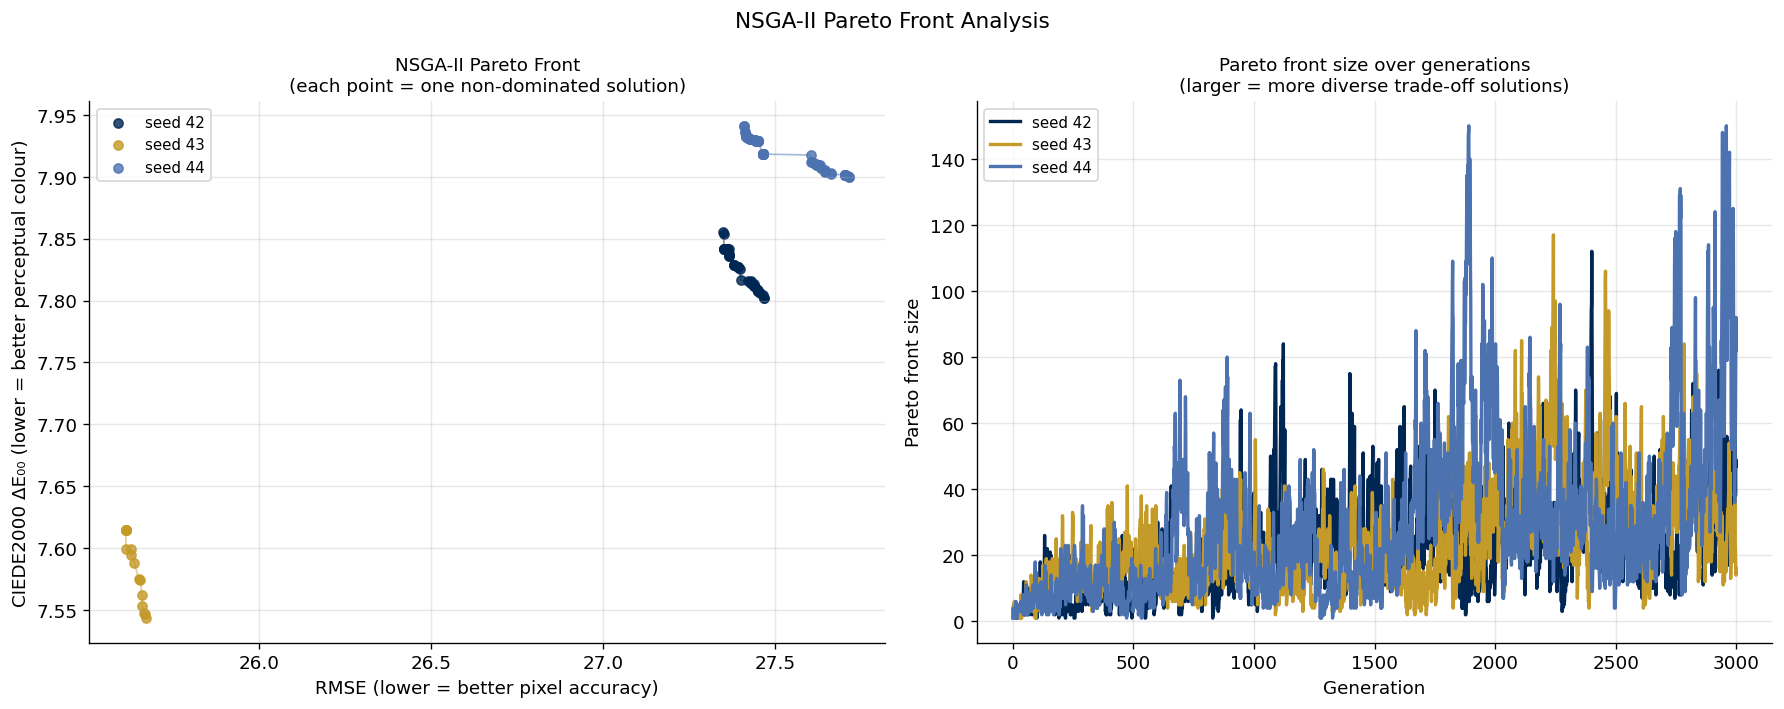

In [ ]:
if not mo_fronts:
    print('No NSGA-II results available yet. Update MO_FOLDER and re-run.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax = axes[0]
    seed_colors = ['#002654', '#C49A28', '#4C72B0']
    for (seed, front), color in zip(mo_fronts.items(), seed_colors):
        rmse_vals  = [ind['fitness_values'][0] for ind in front]
        ciede_vals = [ind['fitness_values'][1] for ind in front]
        # sort by RMSE for a clean curve
        order = np.argsort(rmse_vals)
        ax.scatter([rmse_vals[i] for i in order], [ciede_vals[i] for i in order],
                   color=color, s=30, alpha=0.8, label=f'seed {seed}')
        ax.plot([rmse_vals[i] for i in order], [ciede_vals[i] for i in order],
                color=color, lw=1, alpha=0.5)

    ax.set_xlabel('RMSE (lower = better pixel accuracy)')
    ax.set_ylabel('CIEDE2000 ΔE₀₀ (lower = better perceptual colour)')
    ax.set_title('NSGA-II Pareto Front\n(each point = one non-dominated solution)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Right: front size over generations
    ax = axes[1]
    for (seed, _), color in zip(mo_fronts.items(), seed_colors):
        log = load_log(MO_FOLDER, seed)
        if not log: continue
        gens       = [e['generation'] for e in log]
        front_size = [e.get('front_size', float('nan')) for e in log]
        ax.plot(gens, front_size, color=color, lw=2, label=f'seed {seed}')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Pareto front size')
    ax.set_title('Pareto front size over generations\n(larger = more diverse trade-off solutions)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.suptitle('NSGA-II Pareto Front Analysis', fontsize=13)
    plt.tight_layout()
    plt.savefig('../outputs/challenge1_pareto.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9.1. Pareto Front Analysis Interpretation

The three seeds converged to slightly different regions of the RMSE×CIEDE2000 space — seed 43 at RMSE ~25.7, seeds 42 and 44 at RMSE ~27.3–27.5 — with limited overlap between their Pareto fronts. This inter-seed variability suggests that 3000 generations with a population of 50 are not fully sufficient for the NSGA-II to converge consistently.

The front size plot shows persistent oscillations throughout the run, with the front fluctuating between near-zero and 80–150 individuals. The NSGA-II is continuously losing and recovering diversity rather than stabilising, which is reflected in the seed-to-seed differences in final front position. This variability suggests the NSGA-II would benefit from more generations or a larger population for this problem.

# 10. NSGA-II vs Single-Objective

We plot the single-objective GA results (RMSE and CIEDE2000) as individual points in the same RMSE × CIEDE2000 space as the Pareto front. A solution dominates another if it lies further towards the bottom-left corner — better in both objectives simultaneously.

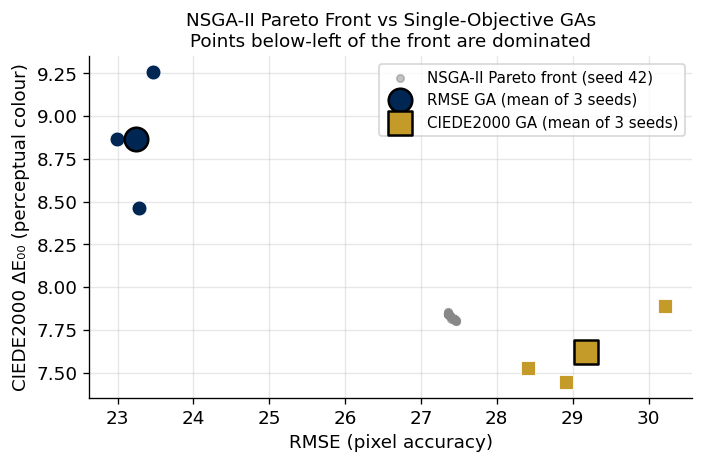

In [111]:
if not mo_fronts:
    print('No NSGA-II results available yet.')
else:
    fig, ax = plt.subplots(figsize=(6, 4))

    # Plot Pareto front (use seed 42 as reference)
    ref_front = mo_fronts.get(42, list(mo_fronts.values())[0])
    rmse_f    = [ind['fitness_values'][0] for ind in ref_front]
    ciede_f   = [ind['fitness_values'][1] for ind in ref_front]
    order     = np.argsort(rmse_f)
    ax.plot([rmse_f[i] for i in order], [ciede_f[i] for i in order],
            color='#888', lw=1.5, linestyle='--', zorder=1)
    ax.scatter([rmse_f[i] for i in order], [ciede_f[i] for i in order],
               color='#888', s=20, alpha=0.5, zorder=2, label='NSGA-II Pareto front (seed 42)')

    # Plot single-objective GA best results
    so_markers = {'RMSE': 'o', 'CIEDE2000': 's', 'SSIM': '^'}
    for name, folder in RUN_FOLDERS.items():
        if name == 'SSIM': continue  # SSIM is not in RMSE/CIEDE space
        subset = df[df['trained_with'] == name]
        for _, row in subset.iterrows():
            ax.scatter(row['rmse'], row['ciede2000'],
                       color=COLORS[name], s=80, marker=so_markers[name],
                       zorder=3, edgecolors='white', linewidths=0.5)
        # mean point with label
        ax.scatter(subset['rmse'].mean(), subset['ciede2000'].mean(),
                   color=COLORS[name], s=200, marker=so_markers[name],
                   zorder=4, edgecolors='black', linewidths=1.5,
                   label=f'{name} GA (mean of 3 seeds)')

    ax.set_xlabel('RMSE (pixel accuracy)', fontsize=11)
    ax.set_ylabel('CIEDE2000 ΔE₀₀ (perceptual colour)', fontsize=11)
    ax.set_title('NSGA-II Pareto Front vs Single-Objective GAs\n'
                 'Points below-left of the front are dominated', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../outputs/challenge1_mo_vs_so.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10.1. NSGA-II vs Single-Objective Interpretation

A solution dominates another if it is better in both objectives simultaneously — graphically, a point dominates another if it lies further towards the bottom-left corner. None of the three GAs dominate each other: the RMSE GA wins on pixel accuracy (RMSE ~23) but loses on perceptual colour (CIEDE ~8.86); the CIEDE GA wins on perceptual colour (CIEDE ~7.62) but loses on pixel accuracy (RMSE ~29); the NSGA-II sits between them (RMSE ~27.3, CIEDE ~7.80).

This means the single-objective GAs already define the extremes of the trade-off space, and the NSGA-II found solutions in the middle. The NSGA-II did not find solutions that are strictly better than both single-objective GAs simultaneously, which is the expected outcome when both objectives are in genuine conflict: you cannot improve one without sacrificing the other. What the NSGA-II adds is the set of intermediate trade-off solutions — points along the front between the two extremes — which a single-objective GA cannot produce by design.

Notably, the NSGA-II's position is closer to the CIEDE2000 end of the trade-off than to the RMSE end — it sacrificed more pixel accuracy than perceptual colour fidelity. This suggests that when both objectives are optimised simultaneously, the algorithm naturally gravitates towards perceptual colour quality, possibly because CIEDE2000 provides a stronger and more consistent optimisation signal, as observed in the convergence analysis.

# 11. NSGA-II Visual Results

The best RMSE and best CIEDE members of the Pareto front, shown alongside the single-objective GA best results and the original.

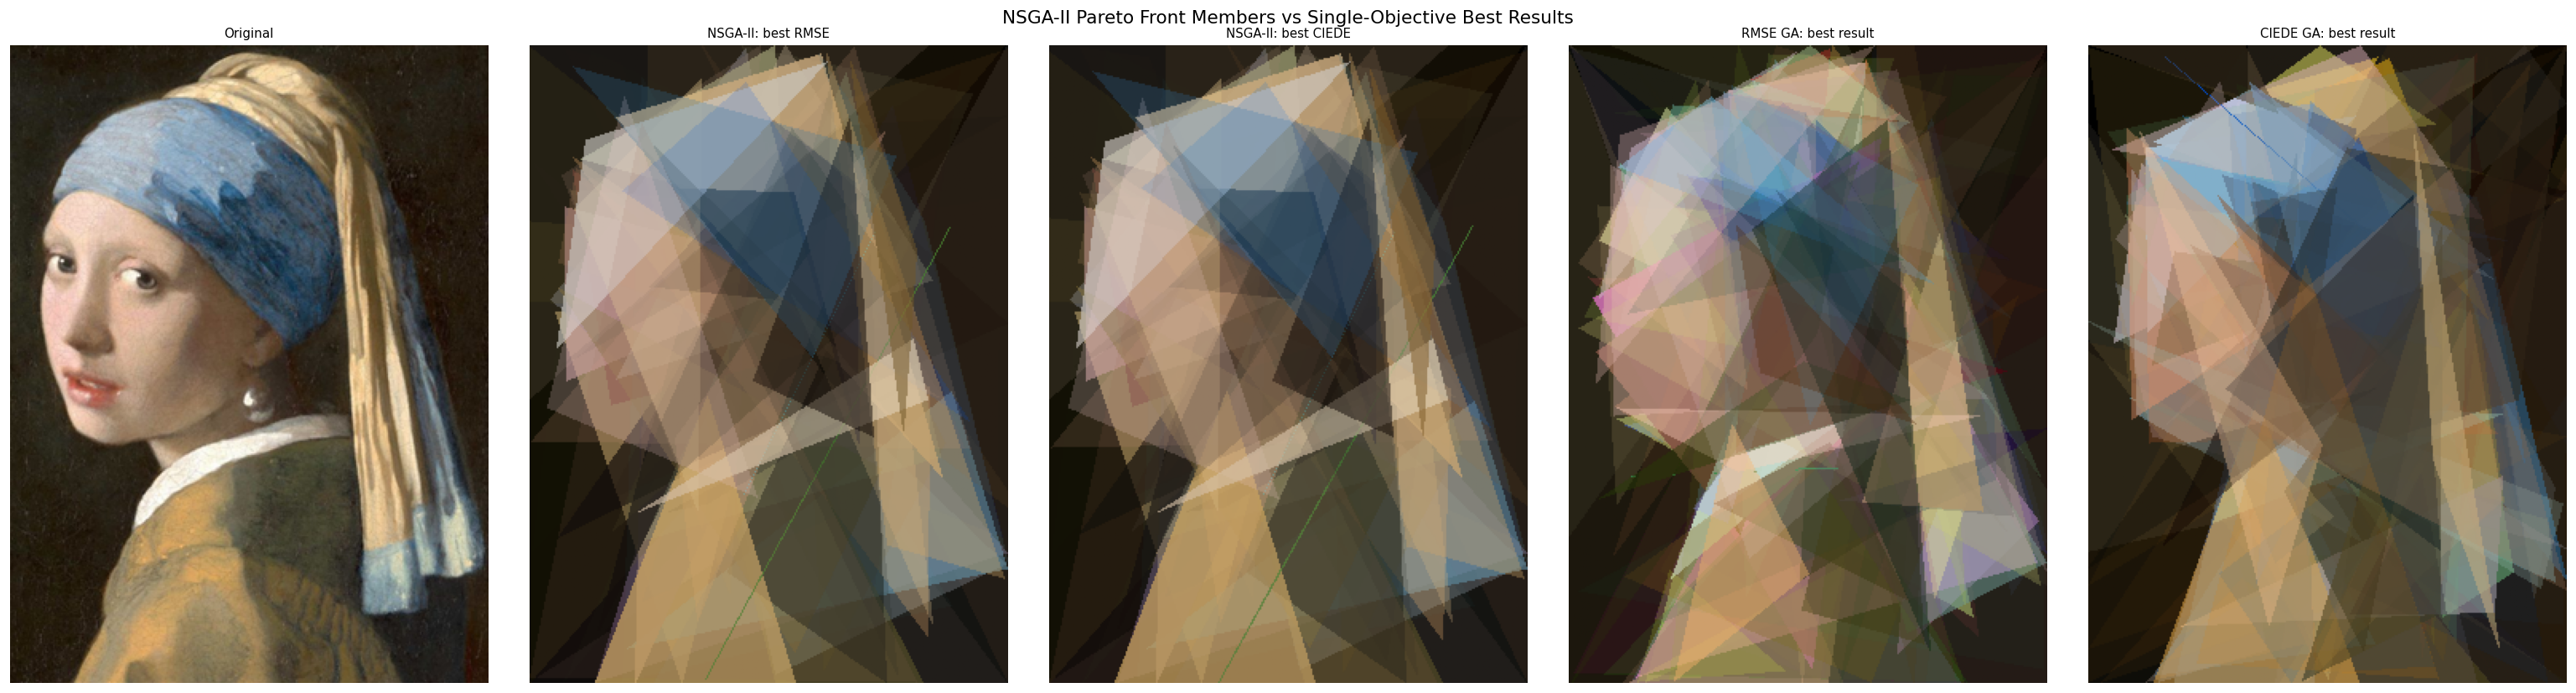

In [114]:
if not mo_fronts:
    print('No NSGA-II results available yet.')
else:
    ref_seed  = 43
    seed_dir  = os.path.join(RUNNER_OUTPUTS, MO_FOLDER, f'seed_{ref_seed}')

    images_to_show = [
        ('Original',              TARGET_PATH),
        ('NSGA-II: best RMSE',    os.path.join(seed_dir, 'best_rmse_individual.png')),
        ('NSGA-II: best CIEDE',   os.path.join(seed_dir, 'best_ciede_individual.png')),
        ('RMSE GA: best result',  os.path.join(RUNNER_OUTPUTS,
                                               RUN_FOLDERS['RMSE'], f'seed_{ref_seed}', 'best_final.png')),
        ('CIEDE GA: best result', os.path.join(RUNNER_OUTPUTS,
                                               RUN_FOLDERS['CIEDE2000'], f'seed_{ref_seed}', 'best_final.png')),
    ]

    fig, axes = plt.subplots(1, len(images_to_show), figsize=(26, 7))
    for ax, (title, path) in zip(axes, images_to_show):
        if os.path.exists(path):
            ax.imshow(mpimg.imread(path))
            ax.set_title(title, fontsize=9)
        else:
            ax.text(0.5, 0.5, 'not found', ha='center', va='center')
        ax.axis('off')

    plt.suptitle('NSGA-II Pareto Front Members vs Single-Objective Best Results',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig('../outputs/challenge1_mo_visual.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11.1. NSGA-II Visual Results Interpretation

The five images make the trade-off tangible in a way that numbers alone cannot.

The two NSGA-II results sit visually between the single-objective extremes — as expected from their position in the scatter plot. The **NSGA-II best RMSE** member shows finer detail and more complex triangle layering, closer in character to the RMSE GA. The **NSGA-II best CIEDE** member is cleaner and more colour-faithful, closer to the CIEDE GA.

What is notable is that the NSGA-II best CIEDE already shows details absent from the single-objective CIEDE GA — the white collar is visible, the transition between face and background is more defined, and the overall structure is slightly more refined. This suggests the simultaneous pressure from the RMSE objective nudged the algorithm towards solutions with better structural detail, even in the member of the front that prioritises perceptual colour. The NSGA-II is genuinely finding a middle ground, not simply replicating one of the two single-objective results.

The RMSE GA remains the most detailed overall, but at the cost of the colour inaccuracies already discussed. The CIEDE GA has the most faithful colours but the coarsest structure. The NSGA-II sits between them — not the best at anything, but the only approach that avoids the worst of both.

# 12. Conclusions

The central question of this challenge was whether replacing the standard RMSE fitness function with a perceptual colour metric produces better results for triangle-based image approximation. The answer is nuanced and depends on what "better" means.

### Key Findings

The central finding of this challenge is that fitness function choice shapes what the GA learns, not merely how efficiently it learns. RMSE and CIEDE2000 both converge successfully, but to fundamentally different solutions — RMSE produces the most pixel-accurate result; CIEDE2000 produces the most colour-faithful result. Neither dominates the other globally, and the right choice depends on what quality means for the application.

The redistribution effect is real: CIEDE2000 directs optimisation effort towards perceptually salient regions, locks in correct colours by generation 500, and converges with lower seed-to-seed variance — making it the more stable and perceptually principled choice when visual resemblance is the goal.

SSIM, while theoretically motivated, does not penalise colour error directly. The GA learns structure without correcting colour, committing to a chromatically incorrect solution it cannot escape. It makes genuine progress throughout 3000 generations, but to the wrong place.

The NSGA-II extends the analysis beyond the binary choice between RMSE and CIEDE2000, making the trade-off between pixel accuracy and perceptual colour fidelity explicit and navigable. The Pareto front reveals that the two objectives are genuinely conflicting — each single-objective GA finds an extreme the other cannot reach — and that intermediate solutions exist which neither approach can produce alone. The NSGA-II naturally gravitates towards the CIEDE2000 end of the front, consistent with CIEDE2000 providing the stronger optimisation signal throughout this challenge.

As future work, it would be valuable to optimise the operator configuration independently for each fitness function, rather than using the RMSE-tuned configuration for all three. 
Similarly, increasing the number of generations and population size, particularly for the NSGA-II, would give each approach more space to explore and likely yield more consistent convergence across seeds.